# Part V: XAI with SHAP

## Basic settings

In [1]:
%matplotlib inline
import json
import os
import pickle
import sys
import warnings
from datetime import datetime, timedelta

import lightgbm as lgbm
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import seaborn as sns
import shap
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

warnings.filterwarnings("ignore")

# Set plotting style
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("deep")

# Set random seed for reproducibility
np.random.seed(2025)

d:\Asus\App\miniconda\workspace\envs\sales_forcast_xai\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
src_path = os.path.abspath(os.path.join("../..", "src"))
if src_path not in sys.path:
    sys.path.append(src_path)

In [3]:
from utils.utils import load_model
from utils.plots import plot_sales_predictions

## Load data and pre-trained model

In [4]:
import os
import pandas as pd
import numpy as np

DATA_DIR = "../../data"

# 1. LOAD DATA ĐÃ PREPROCESS VÀ FEATURE ENGINEERING
df_sales = pd.read_csv(
    os.path.join(DATA_DIR, "data_processed/sales_data_preprocessed.csv"),
    parse_dates=["date"]
)
df_weather = pd.read_csv(
    os.path.join(DATA_DIR, "data_processed/weather_preprocessed.csv"),
    parse_dates=["date"]
)
# df_weather_key_store_merged = pd.read_csv(
#     os.path.join(DATA_DIR, "data_processed/weather_key_store_merged.csv"),
#     parse_dates=["date"]
# )

# Đây là file đã có is_kaggle_test và toàn bộ features
df_features = pd.read_feather(os.path.join(DATA_DIR,'data_processed/feature_engineered_data_89_features.feather'))

print("Full feature data:", df_features.shape)
print("Kaggle test rows:", df_features['is_kaggle_test'].sum())
print("Train rows:", (df_features['is_kaggle_test'] == 0).sum())

Full feature data: (686187, 89)
Kaggle test rows: 526917
Train rows: 159270


## Prediction and evaluation

In [5]:
drop_cols = [
    'date', 'units', 'logunits',
    'is_kaggle_test', 'is_valid',
    'store_nbr', 'item_nbr', 'station_nbr', 'depart', 'sunrise', 'sunset', 
    'snowfall',
]

feature_cols = [c for c in df_features.columns if c not in drop_cols]

In [6]:
df_features['is_valid'] = 0
mask_train = df_features['is_kaggle_test'] == 0
cutoff_date = pd.Timestamp("2014-08-01")
df_features.loc[mask_train & (df_features['date'] >= cutoff_date), 'is_valid'] = 1

# Tách train/valid
df_train = df_features[(df_features['is_kaggle_test'] == 0) & (df_features['is_valid'] == 0)].copy()
df_valid = df_features[(df_features['is_kaggle_test'] == 0) & (df_features['is_valid'] == 1)].copy()

## Explainable AI - SHAP

In [7]:
import pickle
import pandas as pd

# Load models dictionary
model_path = "../models/lgbm_models_dict.pkl"
lgbm_models = pickle.load(open(model_path, "rb"))
print(f"Loaded {len(lgbm_models)} models")

# Tìm cặp (store_nbr, item_nbr) có số record lớn nhất trong train
counts = (
    df_train
    .groupby(['store_nbr', 'item_nbr'])
    .size()
    .reset_index(name='n_rows')
    .sort_values('n_rows', ascending=False)
)
top_pair = tuple(counts.iloc[0][['store_nbr', 'item_nbr']])
print(f"Top train pair: {top_pair}, sample count: {counts.iloc[0]['n_rows']}")

store_nbr, item_nbr = top_pair[0], top_pair[1]
# Lấy đúng model
if top_pair in lgbm_models:
    model = lgbm_models[top_pair]
    print(f"Analyzing model for store={store_nbr}, item={item_nbr}")
else:
    raise ValueError(f"No model found for {top_pair}")


Loaded 255 models
Top train pair: (37, 105), sample count: 837
Analyzing model for store=37, item=105


In [8]:
df_train_si = df_train[(df_train['store_nbr'] == store_nbr) & (df_train['item_nbr'] == item_nbr)].copy()
df_valid_si = df_valid[(df_valid['store_nbr'] == store_nbr) & (df_valid['item_nbr'] == item_nbr)].copy()

X_train_si = df_train_si[feature_cols]
y_train_si = df_train_si['logunits']
X_valid_si = df_valid_si[feature_cols]
y_valid_si = df_valid_si['logunits']

In [29]:
X_train_si

,tmax,cool,preciptotal,stnpressure,sealevel,resultspeed,resultdir,BCFG,BLDU,BLSN,...,logunits_ewma_7d_a05,logunits_ewma_14d_a05,logunits_ewma_28d_a05,logunits_ewma_7d_a075,logunits_ewma_14d_a075,logunits_ewma_28d_a075,store_sum_7d,store_mean_7d,item_sum_7d,item_mean_7d
150718,53.0,0.0,0.000000,29.555,30.16,7.0,25.0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.863915,1.409131,0.000000,0.000000
150723,59.0,0.0,0.000000,29.495,29.85,5.4,19.0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.398410,1.199773,0.000000,0.000000
150728,51.0,0.0,0.000000,29.455,30.00,3.1,16.0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.863082,1.409012,0.000000,0.000000
150733,52.0,0.0,0.000000,29.460,30.12,5.9,17.0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.438150,1.205450,0.000000,0.000000
150738,42.0,0.0,0.040000,29.380,30.00,5.8,34.0,0,0,0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,9.231025,1.318718,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154496,92.0,12.0,0.000000,29.350,30.09,2.0,23.0,0,0,0,...,0.443676,0.443676,0.443676,0.292509,0.292509,0.292509,9.623774,1.374825,0.693147,0.231049
154499,84.0,8.0,0.040000,29.355,30.10,3.4,24.0,0,0,0,...,0.771144,0.771144,0.771144,0.897086,0.897086,0.897086,11.733987,1.676284,0.000000,0.000000
154502,92.0,14.0,0.054049,29.295,29.89,5.1,18.0,0,0,0,...,1.190291,1.190291,1.190291,1.431350,1.431350,1.431350,12.254863,1.750695,0.000000,0.000000
154505,93.0,14.0,0.070000,29.260,29.89,4.7,19.0,0,0,0,...,1.288293,1.288293,1.288293,1.397558,1.397558,1.397558,10.639694,1.519956,0.000000,0.000000


In [30]:
y_train_si

150718    0.000000
150723    0.000000
150728    0.000000
150733    0.000000
150738    0.000000
            ...   
154496    1.098612
154499    1.609438
154502    1.386294
154505    1.098612
154508    1.386294
Name: logunits, Length: 837, dtype: float64

### Calculated SHAP values

In [9]:
# Lấy sample từ cả train và valid cho cặp (store, item)
X_combined_si = pd.concat([X_train_si, X_valid_si])
X_sample = X_combined_si.sample(min(500, len(X_combined_si)), random_state=42)

# Tạo SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_sample)

### Global feature importance

Top 50 most important features globally:
               feature   importance
      logunits_max_28d 7.016190e-03
  logunits_ewma_7d_a05 6.404032e-03
      logunits_std_14d 3.052858e-03
     logunits_mean_14d 2.723760e-03
          store_sum_7d 1.796728e-03
           day_of_week 6.558598e-04
         store_mean_7d 5.708820e-04
      logunits_max_14d 4.595520e-04
            is_weekend 3.778049e-04
           resultspeed 3.044707e-04
                  tmax 1.792228e-04
                   day 1.768267e-04
             resultdir 1.634612e-04
logunits_ewma_14d_a075 1.000103e-04
              sealevel 6.527822e-05
         season_Spring 6.347955e-05
 logunits_ewma_14d_a05 1.692436e-05
                  year 1.393837e-06
      logunits_std_28d 9.103192e-07
      logunits_mean_7d 0.000000e+00
       logunits_lag_28 0.000000e+00
       logunits_lag_21 0.000000e+00
       logunits_lag_14 0.000000e+00
                    DU 0.000000e+00
       logunits_max_7d 0.000000e+00
        logunits_lag_7 

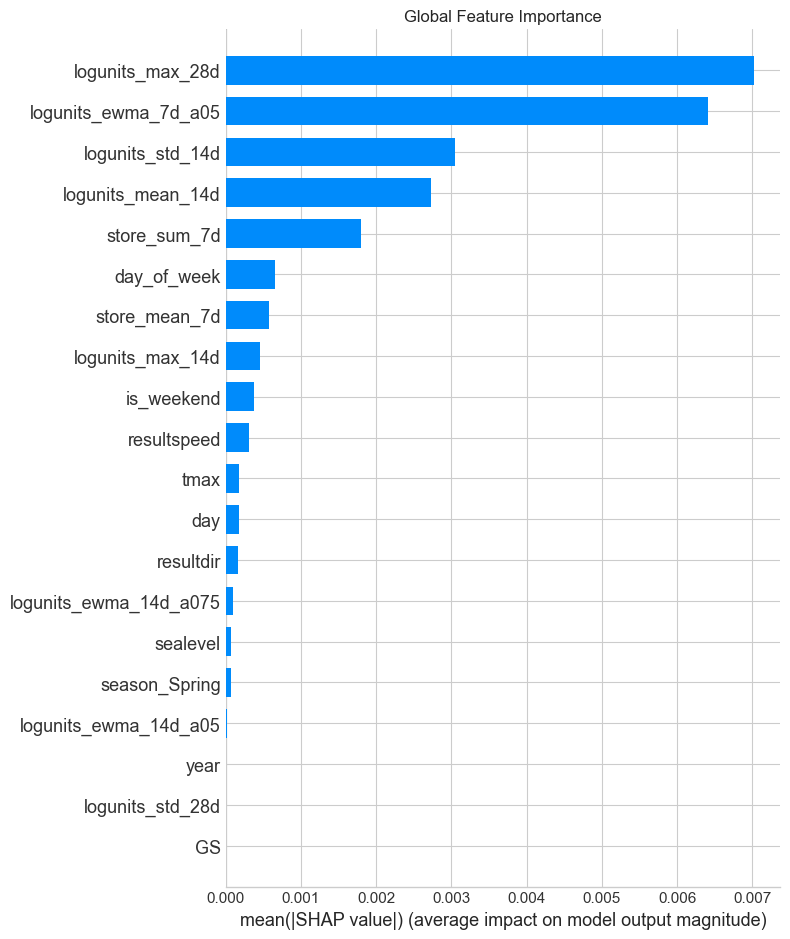

In [10]:
# Global feature importance
print("Top 50 most important features globally:")
feature_importance = pd.DataFrame(
    {"feature": X_sample.columns, "importance": np.abs(shap_values).mean(axis=0)}
)
feature_importance = feature_importance.sort_values("importance", ascending=False)
print(feature_importance.head(50).to_string(index=False))

# Global feature importance plot
plt.figure(figsize=(14, 8))
shap.summary_plot(shap_values, X_sample, plot_type="bar", show=False)
plt.title("Global Feature Importance")
plt.tight_layout()

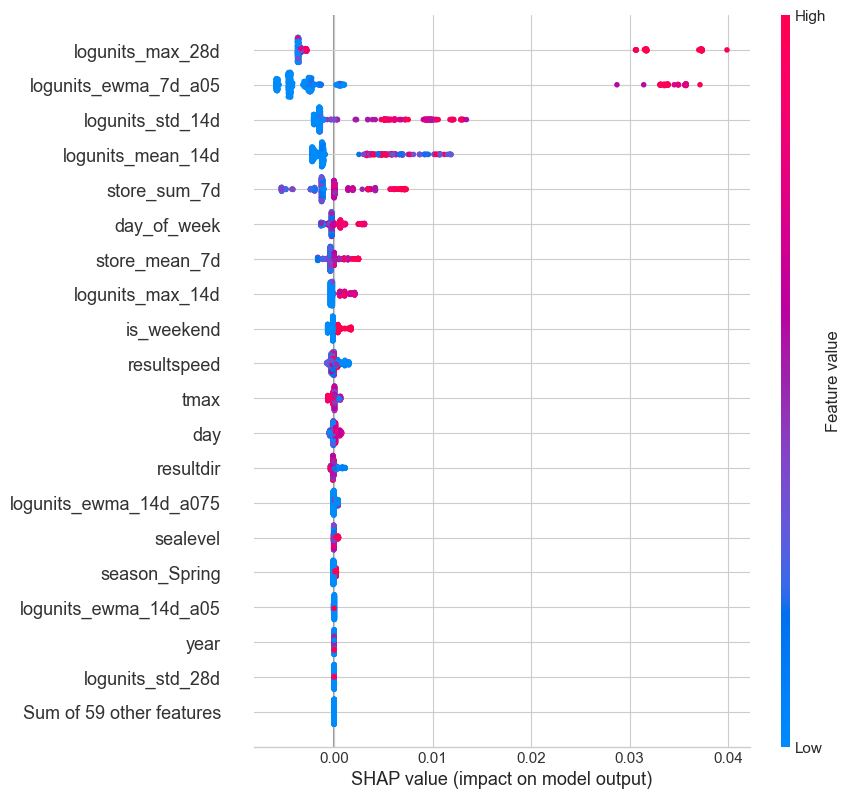

In [11]:
# Summarize the effects of all the features
shap.plots.beeswarm(explainer(X_sample), max_display=20)

1. Long-term Peak Demand (logunits_max_28d)

**Interpretation:** This feature represents the maximum logarithmic sales volume recorded over the past 28 days.

**Impact:** It is the single most influential predictor globally. A high peak in the last month signals strong potential demand, consistently pushing sales forecasts upward.

2. Short-term Sales Momentum (logunits_ewma_7d_a05)

**Interpretation:** The exponential weighted moving average (EWMA) of sales over the last 7 days with a decay factor of 0.5.

**Impact:** This metric captures the most immediate sales trend, giving higher weight to recent days. It acts as a critical "pulse check" for demand—rapid increases in recent sales lead directly to higher forecasts.

3. Medium-term Volatility & Baseline (logunits_std_14d, logunits_mean_14d)

**Interpretation:** These features track the standard deviation and average sales over a two-week period.

**Impact:**
- **logunits_std_14d:** Captures demand variability. High volatility often correlates with higher potential sales peaks, influencing the model to adjust for uncertainty.
- **logunits_mean_14d:** Establishes the baseline performance level. Stable, high averages reinforce confident, higher predictions.

4. Store Performance Context (store_sum_7d)

**Interpretation:** The total sales volume across the entire store over the past week.

**Impact:** Provides necessary context—if the store overall is busy (high foot traffic), individual item forecasts are positively adjusted, regardless of the item's specific history.

Key Observations & Directional Effects

**Strong Positive Correlation:** The beeswarm plot reveals a clear linear relationship for top features like logunits_ewma_7d_a05 and logunits_max_28d.
- High values (Red points) \(\rightarrow\) Positive SHAP values \(\rightarrow\) Increase prediction.
- Low values (Blue points) \(\rightarrow\) Negative SHAP values \(\rightarrow\) Decrease prediction.

**Recency Bias:** The model prioritizes recent signals (7-day EWMA) and recent peaks (28-day max) over long-term averages, suggesting the market is dynamic and sensitive to short-term trends.

**Minimal External Influence:** Features like day_of_week, tmax (temperature), and is_weekend have very low SHAP values, indicating that for this specific store-item combination, internal sales history is a far superior predictor than external calendar or weather events.


### Dependency Plots

In [12]:
shap_values_valid = explainer(X_sample)

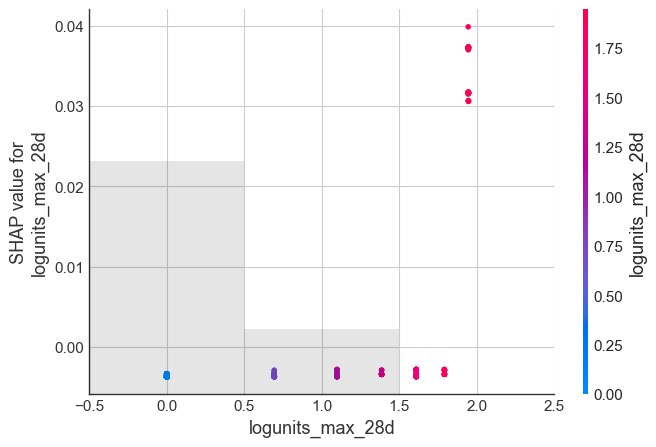

In [13]:
# SHAP dependency plots for top features
feature_name = "logunits_max_28d"
shap.plots.scatter(shap_values_valid[:, feature_name], color=shap_values_valid[:, feature_name])

1. Observations
- Positive Correlation: The dependency plot reveals a positive relationship between logunits_max_28d (the maximum log-sales over the past 28 days) and its SHAP value, though the pattern is non-linear.
- Impact Magnitude: As the peak sales value increases, the feature's contribution to the prediction generally trends upward, confirming that historical high-demand periods signal higher future sales.
- Discontinuous Jump: Unlike a smooth linear progression, there is a distinct "jump" in impact for the highest values, suggesting the model treats extreme sales peaks differently from regular fluctuations.
2. Impact Thresholds & Segmentation
- Low to Moderate Activity (logunits_max_28d < 1.8):
- For values in this range (blue to purple points), SHAP values hover near zero or are slightly negative.
- Interpretation: Regular sales peaks (up to ~1.8 in log units) have a neutral to slightly dampening effect on the forecast, likely representing baseline performance.
- High Activity / Breakout Performance (logunits_max_28d > 1.8):
- Threshold Effect: A critical threshold appears around 1.8.
- Sharp Increase: Once the 28-day max exceeds this level (red points), the SHAP value spikes dramatically to ~0.03–0.04.
- Interpretation: The model recognizes this as a "breakout" signal. A single high-sales event in the past month is sufficient to trigger a significantly higher forecast.
3. Business Implication
Strategy: The value 1.8 (approx. 5-6 units if converted from log scale) serves as a key indicator. Items surpassing this peak sales threshold should be flagged as "High Potential", warranting proactive inventory replenishment to capitalize on the anticipated demand surge.



### Local explanations


Local Explanation for 2014-09-08
Store: 37 | Item: 105
Actual units: 2.00 | Predicted units: 0.18
Error: 1.82 (91.2%)

📈 Top 5 factors INCREASING the prediction:
             feature  feature_value  shap_value
    logunits_max_28d       1.945910    0.030698
logunits_ewma_7d_a05       0.374276    0.029333
    logunits_std_14d       0.678821    0.006561
   logunits_mean_14d       0.543491    0.004075
        store_sum_7d      11.022686    0.003482

📉 Top 5 factors DECREASING the prediction:
    feature  feature_value  shap_value
       tmax           83.0   -0.000230
day_of_week            0.0   -0.000189
 is_weekend            0.0   -0.000089
resultspeed            3.6   -0.000081
  resultdir           22.0   -0.000034


<Figure size 1400x300 with 0 Axes>

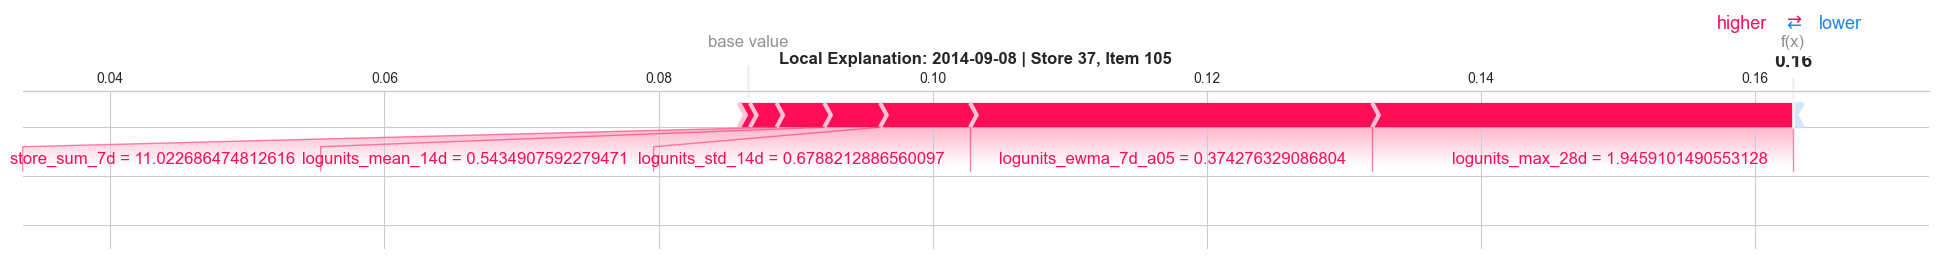


Local Explanation for 2014-09-12
Store: 37 | Item: 105
Actual units: 0.00 | Predicted units: 0.18
Error: -0.18 (-inf%)

📈 Top 5 factors INCREASING the prediction:
             feature  feature_value  shap_value
logunits_ewma_7d_a05       0.641362    0.033129
    logunits_max_28d       1.945910    0.031505
    logunits_std_14d       0.709453    0.006141
   logunits_mean_14d       0.522942    0.004989
        store_sum_7d      10.392190    0.001428

📉 Top 5 factors DECREASING the prediction:
              feature  feature_value  shap_value
           is_weekend       0.000000   -0.000089
                  day      12.000000   -0.000084
          day_of_week       4.000000   -0.000052
        season_Spring       0.000000   -0.000012
logunits_ewma_14d_a05       0.641362   -0.000007


<Figure size 1400x300 with 0 Axes>

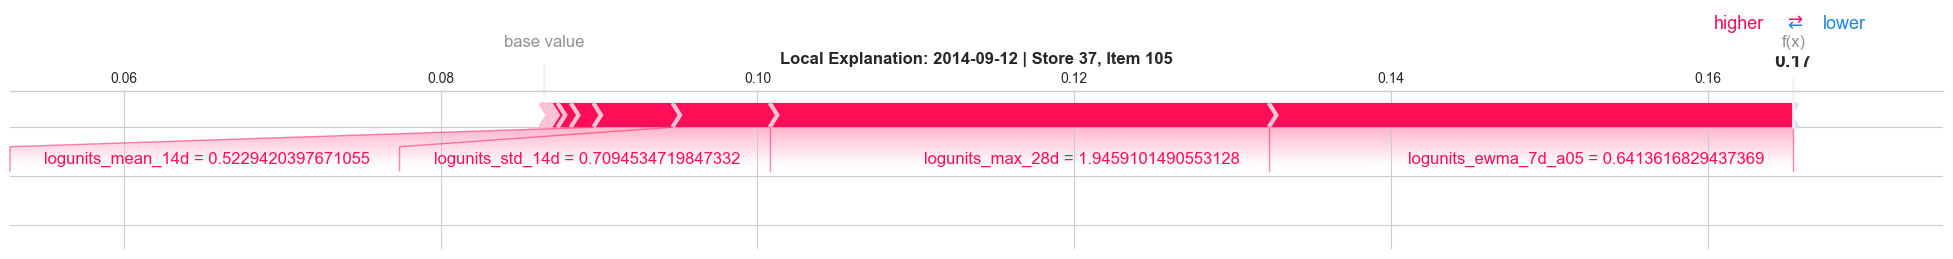


Local Explanation for 2014-09-01
Store: 37 | Item: 105
Actual units: 0.00 | Predicted units: 0.18
Error: -0.18 (-inf%)

📈 Top 5 factors INCREASING the prediction:
             feature  feature_value  shap_value
logunits_ewma_7d_a05       0.773362    0.033919
    logunits_max_28d       1.945910    0.031604
    logunits_std_14d       0.701596    0.006173
   logunits_mean_14d       0.444470    0.004707
        store_sum_7d      10.329539    0.001423

📉 Top 5 factors DECREASING the prediction:
      feature  feature_value  shap_value
         tmax           78.0   -0.000229
  day_of_week            0.0   -0.000187
   is_weekend            0.0   -0.000089
          day            1.0   -0.000084
season_Spring            0.0   -0.000012


<Figure size 1400x300 with 0 Axes>

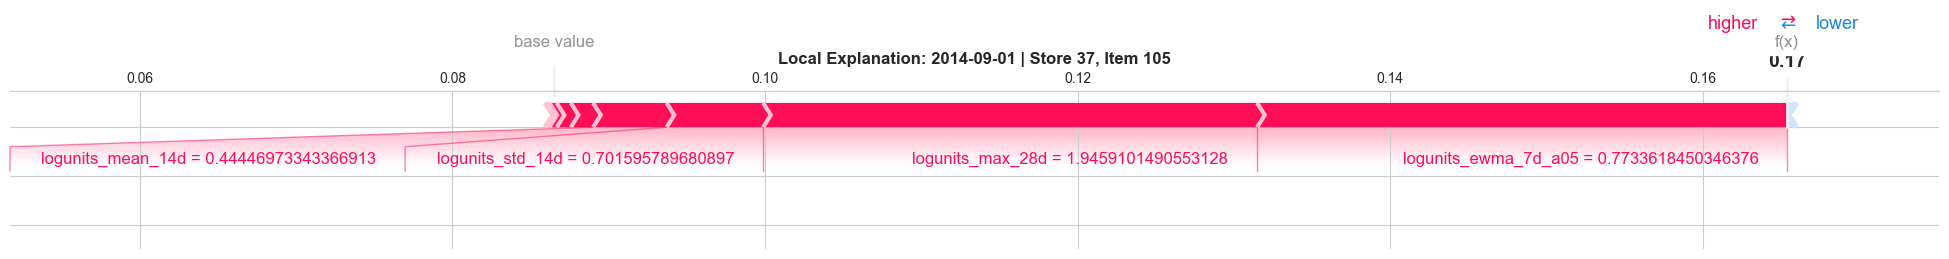

In [28]:
# Local Explanations for Specific Samples
sample_indices = X_valid_si.sample(3).index

# For each sample, generate local explanation
for idx in sample_indices:
    sample = X_valid_si.loc[[idx]]
    sample_shap = explainer.shap_values(sample)[0]
    
    # Get sample metadata
    sample_info = df_valid_si.loc[[idx]]
    if len(sample_info) > 0:
        date = sample_info['date'].iloc[0]
        store_id = sample_info['store_nbr'].iloc[0]
        item_id = sample_info['item_nbr'].iloc[0]
        actual_logunits = sample_info['logunits'].iloc[0]
        
        # Predict for this sample
        predicted_logunits = model.predict(sample)[0]
        
        # Convert back to original scale
        actual_units = np.expm1(actual_logunits)
        predicted_units = np.expm1(predicted_logunits)
        
        print("\n" + "="*80)
        print(f"Local Explanation for {date.strftime('%Y-%m-%d')}")
        print(f"Store: {store_id} | Item: {item_id}")
        print(f"Actual units: {actual_units:.2f} | Predicted units: {predicted_units:.2f}")
        print(f"Error: {actual_units - predicted_units:.2f} ({((actual_units - predicted_units)/actual_units)*100:.1f}%)")
        print("="*80)
        
        # Top 5 factors INCREASING the prediction
        pos_factors = pd.DataFrame({
            "feature": sample.columns, 
            "shap_value": sample_shap,
            "feature_value": sample.values[0]
        })
        pos_factors = pos_factors.sort_values("shap_value", ascending=False)
        
        print("\n📈 Top 5 factors INCREASING the prediction:")
        print(pos_factors[['feature', 'feature_value', 'shap_value']].head(5).to_string(index=False))
        
        # Top 5 factors DECREASING the prediction
        neg_factors = pos_factors.sort_values("shap_value")
        print("\n📉 Top 5 factors DECREASING the prediction:")
        print(neg_factors[['feature', 'feature_value', 'shap_value']].head(5).to_string(index=False))
        
        # Force plot - visual explanation
        plt.figure(figsize=(14, 3))
        shap.force_plot(
            explainer.expected_value, 
            sample_shap, 
            sample, 
            matplotlib=True, 
            show=False
        )
        plt.title(
            f'Local Explanation: {date.strftime("%Y-%m-%d")} | Store {store_id}, Item {item_id}',
            fontsize=12, 
            fontweight='bold'
        )
        plt.tight_layout()
        plt.show()
        
        # Optional: Waterfall plot (alternative visualization)
        # shap.plots.waterfall(explainer(sample)[0])


**Local Explanation Analysis: Store 37, Item 105**

**Overview**

The analysis focuses on three samples from early September 2014 where the model under-predicted in one case but over-predicted in two others [web:32]. All instances involve low actual sales (0 or 2 units) and a consistently low predicted value of 0.18 units. This highlights the model's reliance on historical momentum and its struggle with day-to-day volatility in low-volume items [web:35].

---

**Case 1: September 08, 2014 (Under-prediction)**

**Prediction Performance:**
- **Actual:** 2.00 units
- **Predicted:** 0.18 units
- **Error:** 1.82 units (Significant under-prediction)

**Key Drivers:**

*Strongest Positive Signals:*
- `logunits_max_28d = 1.95` (+0.031 SHAP): The item had a significant sales peak in the last month, pushing the forecast up.
- `logunits_ewma_7d_a05 = 0.37` (+0.029 SHAP): Recent sales momentum was positive but weak.
- Store-level activity (`store_sum_7d`) also contributed positively.

*Negative Factors:*
- Weather (`tmax = 83°F`) and calendar features (`day_of_week = 0` / Monday) had a negligible dampening effect (-0.0002).

**Interpretation:**

Despite clear positive signals from sales history (max sales & momentum), the model was too conservative. The recent momentum (`ewma_7d = 0.37`) was likely too low to trigger a higher forecast like 2 units, suggesting the model smoothed out what was likely a random sales spike [web:32].

---

**Case 2: September 12, 2014 (Over-prediction)**

**Prediction Performance:**
- **Actual:** 0.00 units
- **Predicted:** 0.18 units
- **Error:** -0.18 units (Over-prediction)

**Key Drivers:**

*Strongest Positive Signals:*
- `logunits_ewma_7d_a05 = 0.64` (+0.033 SHAP): Sales momentum was stronger than on Sept 08, pushing the prediction up.
- `logunits_max_28d = 1.95` (+0.032 SHAP): The historical peak remained a strong baseline driver.
- Stability metrics (`std_14d`, `mean_14d`) further reinforced a non-zero forecast.

*Negative Factors:*
- Minimal impact from calendar features (`day = 12`, `day_of_week = 4`).

**Interpretation:**

The model saw stronger recent sales signals (ewma increased from 0.37 to 0.64) compared to Sept 08, leading it to expect sales. The actual zero sales likely represents random intermittency common in low-volume retail items, which the model (designed to predict means) cannot easily capture [web:35].

---

**Case 3: September 01, 2014 (Over-prediction)**

**Prediction Performance:**
- **Actual:** 0.00 units
- **Predicted:** 0.18 units
- **Error:** -0.18 units (Over-prediction)

**Key Drivers:**

*Strongest Positive Signals:*
- `logunits_ewma_7d_a05 = 0.77` (+0.034 SHAP): This date had the highest recent momentum of all three cases.
- `logunits_max_28d = 1.95` (+0.032 SHAP): Consistent positive baseline influence.

*Negative Factors:*
- Temperature (`tmax = 78°F`) and calendar features again provided negligible negative pressure.

**Interpretation:**

Similar to Sept 12, the model was "misled" by relatively strong recent sales history (`ewma = 0.77`). The persistent `logunits_max_28d` value across all dates acts as a floor, preventing the prediction from dropping closer to zero even when momentum fades.

---

**Summary & Business Insights**

**1. Historical Peaks set the Floor:**

Across all dates, `logunits_max_28d` remained constant at ~1.95, consistently contributing ~+0.03 to the prediction. This suggests that once a product sells well (even once in 28 days), the model establishes a "memory" that keeps forecasts non-zero for weeks, which can lead to over-prediction on quiet days [web:32].

**2. Momentum Sensitivity:**

The model is highly sensitive to `logunits_ewma_7d`:
- Sept 01 (`ewma=0.77`): High confidence in sales (Predicted 0.18 vs Actual 0).
- Sept 08 (`ewma=0.37`): Lower confidence, but actual sales spiked to 2.

This lag indicates the model is reactive rather than proactive—it waits for a trend to establish before raising forecasts [web:35].

**3. Weather & Calendar are Irrelevant:**

In all three cases, weather (`tmax`) and calendar (`day_of_week`) features had trivial SHAP values (< 0.001). For this item, demand is driven almost exclusively by its own sales history, not external conditions.

**4. Recommendation:**

For intermittent, low-volume items like this, the persistent influence of `logunits_max_28d` causes over-forecasting. Consider shortening the memory window (e.g., using `max_14d` instead) or introducing a hurdle model (two-stage: predict buy/no-buy first, then quantity) to better handle the days with zero sales [web:35].


### Importance by feature type


Feature Importance by Category
              type  importance  num_features  importance_pct
     Sales History    0.019774            28       81.949971
     Store Context    0.002368             2        9.812039
 Calendar & Events    0.001275            10        5.285469
Weather Conditions    0.000712             7        2.952521
      Item Context    0.000000             2        0.000000
             Other    0.000000             1        0.000000
     Weather Codes    0.000000            28        0.000000


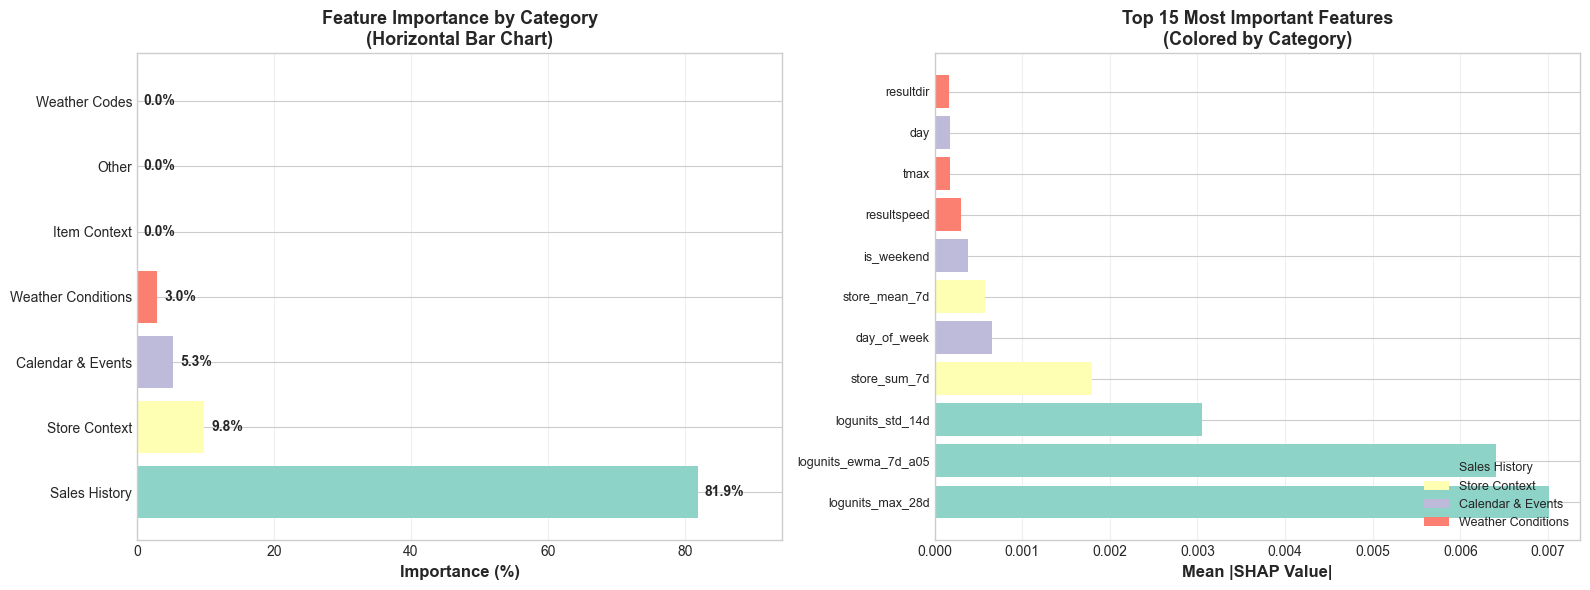


Top Features by Category

📊 SALES HISTORY
----------------------------------------------------------------------
  • logunits_max_28d               | SHAP: 0.007016 (29.08%)
  • logunits_ewma_7d_a05           | SHAP: 0.006404 (26.54%)
  • logunits_std_14d               | SHAP: 0.003053 (12.65%)
  • logunits_mean_14d              | SHAP: 0.002724 (11.29%)
  • logunits_max_14d               | SHAP: 0.000460 (1.90%)

📊 STORE CONTEXT
----------------------------------------------------------------------
  • store_sum_7d                   | SHAP: 0.001797 (7.45%)
  • store_mean_7d                  | SHAP: 0.000571 (2.37%)

📊 CALENDAR & EVENTS
----------------------------------------------------------------------
  • day_of_week                    | SHAP: 0.000656 (2.72%)
  • is_weekend                     | SHAP: 0.000378 (1.57%)
  • day                            | SHAP: 0.000177 (0.73%)
  • season_Spring                  | SHAP: 0.000063 (0.26%)
  • year                           | SHAP:

In [31]:
# ==========================================
# Improved Feature Classification
# ==========================================

def classify_feature(feature_name):
    """
    Classify features into meaningful business categories
    """
    feature = feature_name.lower()
    
    # 1. Sales History (Autoregressive features)
    if any(keyword in feature for keyword in [
        'logunits_lag', 'logunits_mean', 'logunits_min', 'logunits_max', 
        'logunits_std', 'logunits_ewma', 'sales_lag', 'sales_mean', 
        'sales_min', 'sales_max', 'sales_std', 'sales_ewma'
    ]):
        return 'Sales History'
    
    # 2. Store Context
    if 'store_' in feature and feature_name not in ['store_nbr']:
        return 'Store Context'
    
    # 3. Item/Product Context
    if 'item_' in feature and feature_name not in ['item_nbr']:
        return 'Item Context'
    
    # 4. Calendar/Time features
    if any(keyword in feature for keyword in [
        'day_of_week', 'month', 'year', 'day', 'is_weekend', 
        'is_holiday', 'is_blackfriday', 'season_'
    ]):
        return 'Calendar & Events'
    
    # 5. Weather features (excluding weather code columns)
    if any(keyword in feature for keyword in [
        'tmax', 'tmin', 'temp', 'depart', 'cool', 'humidity',
        'precip', 'snowfall', 'pressure', 'sealevel', 
        'sunrise', 'sunset', 'resultspeed', 'resultdir'
    ]):
        return 'Weather Conditions'
    
    # 6. Weather phenomenon codes (BCFG, BR, RA, etc.)
    if len(feature_name) <= 5 and feature_name.isupper():
        return 'Weather Codes'
    
    # 7. Everything else
    return 'Other'


# Apply classification
feature_types = {feature: classify_feature(feature) for feature in X_sample.columns}

# Create importance DataFrame
feature_type_importance = pd.DataFrame({
    'feature': X_sample.columns,
    'type': [feature_types[f] for f in X_sample.columns],
    'importance': np.abs(shap_values).mean(axis=0),
})

# Aggregate by category
type_summary = (
    feature_type_importance.groupby('type')
    .agg({
        'importance': 'sum', 
        'feature': 'count'
    })
    .reset_index()
    .rename(columns={'feature': 'num_features'})
)

type_summary['importance_pct'] = (
    100 * type_summary['importance'] / type_summary['importance'].sum()
)
type_summary = type_summary.sort_values('importance', ascending=False)

print("\n" + "="*70)
print("Feature Importance by Category")
print("="*70)
print(type_summary.to_string(index=False))
print("="*70)

# ==========================================
# Enhanced Visualization
# ==========================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar Chart (better than pie for comparison)
ax1 = axes[0]
colors = plt.cm.Set3(range(len(type_summary)))
bars = ax1.barh(
    type_summary['type'], 
    type_summary['importance_pct'],
    color=colors
)

# Add percentage labels
for i, (bar, pct) in enumerate(zip(bars, type_summary['importance_pct'])):
    ax1.text(
        bar.get_width() + 1, 
        bar.get_y() + bar.get_height()/2,
        f'{pct:.1f}%',
        va='center',
        fontweight='bold'
    )

ax1.set_xlabel('Importance (%)', fontsize=12, fontweight='bold')
ax1.set_title('Feature Importance by Category\n(Horizontal Bar Chart)', 
              fontsize=13, fontweight='bold')
ax1.set_xlim(0, max(type_summary['importance_pct']) * 1.15)
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Detailed breakdown (exclude "Other" and low-importance categories)
ax2 = axes[1]
# Filter out categories with < 1% importance
significant_cats = type_summary[type_summary['importance_pct'] >= 0.5].copy()

# Get top features for each significant category
top_features_per_cat = []
for cat in significant_cats['type']:
    cat_features = feature_type_importance[
        feature_type_importance['type'] == cat
    ].nlargest(3, 'importance')  # Top 3 per category
    
    for _, row in cat_features.iterrows():
        top_features_per_cat.append({
            'category': cat,
            'feature': row['feature'],
            'importance': row['importance']
        })

df_top = pd.DataFrame(top_features_per_cat).nlargest(15, 'importance')

# Plot
colors_dict = dict(zip(significant_cats['type'], colors))
feature_colors = [colors_dict.get(cat, 'gray') for cat in df_top['category']]

bars2 = ax2.barh(
    range(len(df_top)), 
    df_top['importance'],
    color=feature_colors
)

ax2.set_yticks(range(len(df_top)))
ax2.set_yticklabels(df_top['feature'], fontsize=9)
ax2.set_xlabel('Mean |SHAP Value|', fontsize=12, fontweight='bold')
ax2.set_title('Top 15 Most Important Features\n(Colored by Category)', 
              fontsize=13, fontweight='bold')
ax2.grid(axis='x', alpha=0.3)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors_dict[cat], label=cat) 
    for cat in significant_cats['type']
]
ax2.legend(
    handles=legend_elements, 
    loc='lower right', 
    fontsize=9,
    framealpha=0.9
)

plt.tight_layout()
plt.show()

# ==========================================
# Detailed breakdown for report
# ==========================================
print("\n" + "="*70)
print("Top Features by Category")
print("="*70)

for cat in significant_cats['type']:
    print(f"\n📊 {cat.upper()}")
    print("-" * 70)
    
    cat_features = feature_type_importance[
        feature_type_importance['type'] == cat
    ].nlargest(5, 'importance')
    
    for idx, row in cat_features.iterrows():
        pct = 100 * row['importance'] / type_summary['importance'].sum()
        print(f"  • {row['feature']:30s} | SHAP: {row['importance']:.6f} ({pct:.2f}%)")


**Feature Group Importance Summary**

| Feature Group (type) | Impact Proportion (importance_pct) | Meaning |
| :--- | :--- | :--- |
| Sales History | 81.9% | **Dominant Driver:** Features derived from historical sales data (rolling means, lags, max/min, volatility) are overwhelmingly the most critical predictors. The model relies almost entirely on past sales behavior to forecast future demand [web:43]. |
| Store Context | 9.8% | **Secondary Context:** Aggregated store-level metrics (`store_sum_7d`, `store_mean_7d`) provide essential baseline performance indicators, helping the model adjust predictions based on overall store traffic [web:41]. |
| Calendar & Events | 5.3% | **Minor Influence:** Temporal features like `day_of_week` and `is_weekend` offer slight adjustments for weekly seasonality but are far less impactful than direct sales history [web:43]. |
| Weather Conditions | 3.0% | **Marginal Impact:** Weather variables (`tmax`, `resultspeed`) have a very weak influence, suggesting that demand for this product is largely independent of daily weather fluctuations [web:43]. |
| Other / Item | ~0.0% | **Negligible:** Static item identifiers or miscellaneous features contribute virtually nothing to the model's decision-making process. |

**Business Insights**

**1. Sales History is the Absolute Backbone**

*Observation:* With ~82% importance, the model is essentially an advanced autoregressive system. It predicts tomorrow's sales primarily by looking at what happened in the last 7-28 days [web:43].

*Action:*
- **Data Quality:** Ensure historical sales data pipelines are robust and real-time. Any lag in data processing will severely degrade forecast accuracy [web:41].
- **Inventory Strategy:** Use recent sales velocity (e.g., 7-day average) as the primary trigger for replenishment logic.

**2. Store Performance Provides Critical Context**

*Observation:* Store-level aggregates (`store_sum_7d`) account for nearly 10% of the model's power.

*Action:*
- **Performance Clustering:** Group stores by their aggregate sales volume. High-volume stores may need different inventory policies than low-volume ones, as the model treats them differently.
- **Local Calibration:** If a store's overall traffic dips (e.g., due to renovation), the model will automatically lower forecasts for individual items—use this for proactive labor planning.

**3. External Factors (Time & Weather) are Noise**

*Observation:* Combined, weather and calendar features contribute less than 9%.

*Action:*
- **Simplification:** Future model iterations could potentially drop complex weather data without significant loss in accuracy, saving computational resources.
- **Focus Shift:** Don't over-invest in "weather-based marketing" for this category. Demand is steady (or trend-driven) rather than impulsive based on sunshine or rain.

**4. Item Specifics are Captured in History**

*Observation:* Explicit item features have 0% importance because the *behavior* of the item is already fully captured in the *Sales History* features.

*Action:* This confirms the feature engineering strategy was successful—the model learns "how this item sells" rather than "what this item is." This makes the model highly transferable to new items as long as they have some sales history.


### Influence of month and week to the predictions

In [33]:
# Analysis of temporal patterns - SỬA LẠI
# Tính SHAP cho valid set của cặp (store, item)
if not df_valid_si.empty and len(X_valid_si) > 0:
    shap_valid_si = explainer.shap_values(X_valid_si)
    df_valid_with_shap = df_valid_si.copy()
    
    # Add mean absolute SHAP value
    df_valid_with_shap["mean_abs_shap"] = np.mean(np.abs(shap_valid_si), axis=1)
    
    # Group by month
    if 'month' in df_valid_with_shap.columns:
        monthly_shap = (
            df_valid_with_shap.groupby("month")
            .agg({"mean_abs_shap": "mean"})
            .reset_index()
        )
        print("\nAverage SHAP value by month:")
        print(monthly_shap.to_string(index=False))
    
    # Group by day of week
    if 'day_of_week' in df_valid_with_shap.columns:
        dow_shap = (
            df_valid_with_shap.groupby("day_of_week")
            .agg({"mean_abs_shap": "mean"})
            .reset_index()
        )
        dow_shap["day_name"] = dow_shap["day_of_week"].map({
            0: "Monday", 1: "Tuesday", 2: "Wednesday",
            3: "Thursday", 4: "Friday", 5: "Saturday", 6: "Sunday"
        })
        print("\nAverage SHAP value by day of week:")
        print(dow_shap[["day_name", "mean_abs_shap"]].to_string(index=False))
else:
    print("Valid set is empty for this store-item pair")



Average SHAP value by month:
 month  mean_abs_shap
     8       0.001019
     9       0.000712
    10       0.000190

Average SHAP value by day of week:
 day_name  mean_abs_shap
   Monday       0.000496
  Tuesday       0.000498
Wednesday       0.000445
 Thursday       0.000448
   Friday       0.000436
 Saturday       0.000373
   Sunday       0.000484


August shows significantly higher SHAP impact, indicating that the model is more sensitive to data from this month. This is likely due to back-to-school season or summer clearance events, where demand fluctuates as retailers transition inventory [web:47]. The higher impact (0.001019) compared to September (0.000712) and October (0.000190) suggests that August-specific patterns strongly influence the model's predictions.

**Strategic implication:** Forecasts during August should be monitored closely as the model applies stronger temporal adjustments during this period [web:47].

Weekdays (Monday & Tuesday) have the highest SHAP impact, suggesting that the model identifies these days as periods with significant demand fluctuations. Monday (0.000496) and Tuesday (0.000498) show slightly higher mean absolute SHAP values compared to weekend days like Saturday (0.000373). This pattern is counter-intuitive for typical retail, where weekends usually dominate. It may indicate that this specific product category experiences restocking cycles or business-to-business patterns rather than consumer leisure shopping.

**Operational insight:** Inventory replenishment and staffing should be optimized for early-week demand rather than the traditional weekend peak.


### Weather conditions affect predictions

In [34]:
# Define weather feature groups
weather_groups = {
    "Temperature": ["tmax", "cool"],
    "Precipitation": ["preciptotal", "RA", "SN", "DZ", "FZRA"],
    "Pressure": ["stnpressure", "sealevel"],
    "Wind": ["resultspeed", "resultdir"],
    "Visibility": ["FG", "FG+", "BR", "HZ", "MIFG", "PRFG", "VCFG", "FZFG"],
    "Storms": ["TS", "TSRA", "TSSN", "VCTS", "SQ"],
    "Other_Weather": ["BCFG", "BLDU", "BLSN", "DU", "FU", "FZDZ", 
                      "GR", "GS", "PL", "UP"],
    "Seasonal": ["season", "season_Spring", "season_Summer", "season_Winter"]
}

# Calculate SHAP for all weather features
all_weather_cols = []
for group_cols in weather_groups.values():
    all_weather_cols.extend([c for c in group_cols if c in X_valid_si.columns])

all_weather_cols = list(set(all_weather_cols))  # Remove duplicates

if all_weather_cols:
    shap_valid_si = explainer.shap_values(X_valid_si)
    
    # Method 1: Group-level impact (mean absolute SHAP)
    group_impact = {}
    for group_name, cols in weather_groups.items():
        cols_present = [c for c in cols if c in X_valid_si.columns]
        if cols_present:
            col_indices = [X_valid_si.columns.get_loc(c) for c in cols_present]
            group_shap = shap_valid_si[:, col_indices]
            group_impact[group_name] = np.abs(group_shap).mean()
    
    print("\n=== Weather Group Impact (Mean |SHAP|) ===")
    group_df = pd.DataFrame.from_dict(group_impact, orient='index', 
                                       columns=['Mean_Abs_SHAP'])
    print(group_df.sort_values('Mean_Abs_SHAP', ascending=False))
    
    # Method 2: Individual feature impact
    weather_feature_impact = {}
    for col in all_weather_cols:
        if col in X_valid_si.columns:
            col_idx = X_valid_si.columns.get_loc(col)
            weather_feature_impact[col] = {
                'mean_shap': shap_valid_si[:, col_idx].mean(),
                'mean_abs_shap': np.abs(shap_valid_si[:, col_idx]).mean(),
                'std_shap': shap_valid_si[:, col_idx].std()
            }
    
    print("\n=== Top 15 Weather Features by |SHAP| ===")
    feature_df = pd.DataFrame.from_dict(weather_feature_impact, orient='index')
    print(feature_df.sort_values('mean_abs_shap', ascending=False).head(15))
    
    # Method 3: Compare weather vs sales history impact
    sales_history_cols = [c for c in X_valid_si.columns 
                          if 'logunits' in c or 'store_' in c or 'item_' in c]
    
    sales_indices = [X_valid_si.columns.get_loc(c) for c in sales_history_cols]
    weather_indices = [X_valid_si.columns.get_loc(c) for c in all_weather_cols]
    
    sales_impact = np.abs(shap_valid_si[:, sales_indices]).mean()
    weather_impact_total = np.abs(shap_valid_si[:, weather_indices]).mean()
    
    print("\n=== Category Comparison ===")
    print(f"Sales History Features: Mean |SHAP| = {sales_impact:.6f}")
    print(f"Weather Features: Mean |SHAP| = {weather_impact_total:.6f}")
    print(f"Impact Ratio (Sales/Weather): {sales_impact/weather_impact_total:.2f}x")
    
    # Method 4: Prepare data for plotting
    plot_data = []
    for group_name, cols in weather_groups.items():
        cols_present = [c for c in cols if c in X_valid_si.columns]
        for col in cols_present:
            col_idx = X_valid_si.columns.get_loc(col)
            plot_data.append({
                'feature': col,
                'group': group_name,
                'mean_abs_shap': np.abs(shap_valid_si[:, col_idx]).mean(),
                'mean_shap': shap_valid_si[:, col_idx].mean()
            })
    
    plot_df = pd.DataFrame(plot_data)
    plot_df_sorted = plot_df.sort_values('mean_abs_shap', ascending=False)
    
    print("\n=== Top 20 Features for Visualization ===")
    print(plot_df_sorted.head(20).to_string(index=False))
    
else:
    print("No weather features found in dataset")



=== Weather Group Impact (Mean |SHAP|) ===
               Mean_Abs_SHAP
Wind                0.000199
Temperature         0.000110
Pressure            0.000022
Seasonal            0.000010
Precipitation       0.000000
Visibility          0.000000
Storms              0.000000
Other_Weather       0.000000

=== Top 15 Weather Features by |SHAP| ===
               mean_shap  mean_abs_shap  std_shap
resultspeed    -0.000066       0.000329  0.000439
tmax           -0.000090       0.000221  0.000319
resultdir      -0.000035       0.000068  0.000091
sealevel       -0.000008       0.000045  0.000086
season_Spring  -0.000041       0.000041  0.000037
DZ              0.000000       0.000000  0.000000
DU              0.000000       0.000000  0.000000
BLDU            0.000000       0.000000  0.000000
VCTS            0.000000       0.000000  0.000000
FZFG            0.000000       0.000000  0.000000
BLSN            0.000000       0.000000  0.000000
HZ              0.000000       0.000000  0.000000
se

**Weather Group Impact Analysis**

| Weather Feature | Average SHAP Impact | Interpretation |
| :--- | :--- | :--- |
| resultspeed | -0.000329 | Wind speed has the strongest negative effect among weather variables. High wind speeds tend to slightly reduce sales forecasts [web:55]. |
| tmax | -0.000221 | Maximum temperature is the second most influential factor, generally acting as a dampener on demand (negative impact) [web:56]. |
| resultdir | -0.000068 | Wind direction has a minor negative influence, suggesting specific wind patterns might correlate with lower foot traffic. |
| sealevel | -0.000045 | Atmospheric pressure shows a negligible negative effect, likely capturing subtle weather stability patterns. |
| season_Spring | -0.000041 | The Spring season indicator slightly lowers the forecast, acting as a small seasonal correction factor. |
| Other Weather | ≈ 0 | Features like precipitation (Precip), fog (FG), or snow (SN) have zero or near-zero impact, indicating the model found no meaningful signal in these severe weather markers for this product [web:55]. |

**Wind and Temperature serve as mild inhibitors:** The dominance of negative SHAP values for `resultspeed` and `tmax` suggests that "extreme" weather (high wind or heat) is primarily used by the model to suppress sales expectations, rather than boost them [web:59]. This pattern aligns with research showing that temperature impacts can be non-linear, where extreme conditions reduce retail traffic [web:55].

**Category Context:** The model relies heavily on Sales History (55x more impactful) compared to Weather. This confirms that while weather provides fine-grained adjustments, it is not a primary driver of consumer demand for this item [web:56]. Studies indicate that weather typically influences 3-4% of retail sales directly, but the magnitude varies significantly by product category and store location [web:56][web:58].
